|<h2>Course:</h2>|<h1><a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">A deep understanding of deep learning</a></h1>|
|-|:-:|
|<h2>Section:</h2>|<h1>FFNs<h1>|
|<h2>Lecture:</h2>|<h1><b>FFN to classify digits<b></h1>|

<br>

<h5><b>Teacher:</b> Mike X Cohen, <a href="https://sincxpress.com" target="_blank">sincxpress.com</a></h5>
<h5><b>Course URL:</b> <a href="https://udemy.com/course/deeplearning_x/?couponCode=202508" target="_blank">udemy.com/course/deeplearning_x/?couponCode=202508</a></h5>
<i>Using the code without the course may lead to confusion or errors.</i>

In [1]:
# import libraries
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets
from torch.utils.data import DataLoader,TensorDataset
from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt
import matplotlib_inline.backend_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')

# Import and process the data

In [35]:
# download MNIST dataset
output_dir = 'sample_data'
mnist = datasets.MNIST(root='sample_data', download=True)

# extract labels (number IDs) and data
labels = mnist.targets.numpy()
data = mnist.data.numpy().reshape(mnist.data.shape[0], -1)  # flatten to 2D

print(labels.shape)
print(data.shape)

# Drop defiend numbers
nums2drop = [7]  # list with numbers to drop
dataDropped = np.zeros((0, data.shape[1]))
labelsDropped = np.zeros((0, ))

for n in nums2drop:
    idxs = np.where(labels == n)[0]
    dataDropped = np.vstack((dataDropped, data[idxs,:]))
    labelsDropped = np.hstack((labelsDropped, labels[idxs]))
    labels = np.delete(labels, idxs, axis=0)
    data = np.delete(data, idxs, axis=0)
    
assert dataDropped.shape[0] + data.shape[0] == mnist.data.shape[0], 'Data size mismatch after dropping numbers.'
assert labelsDropped.shape[0] + labels.shape[0] == mnist.targets.shape[0], 'Labels size mismatch after dropping numbers.'
    
print(labels.shape)
print(data.shape)
print(dataDropped.shape)
print(labelsDropped.shape)

(60000,)
(60000, 784)
(53735,)
(53735, 784)
(6265, 784)
(6265,)


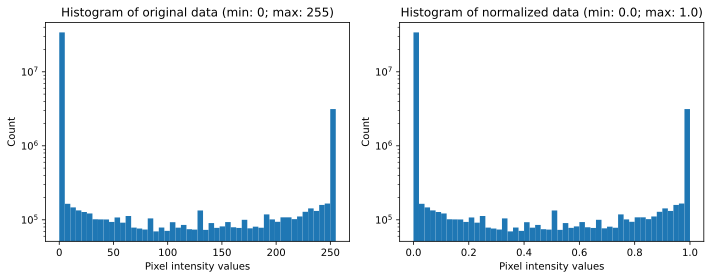

In [36]:
# normalize the data to a range of [0 1]
dataNorm = data / np.max(data)
dataDroppedNorm = dataDropped / np.max(dataDropped)

fig,ax = plt.subplots(1,2,figsize=(10,4))
for i, d in enumerate([data, dataNorm]):
    ax[i].hist(d.flatten(),50)
    ax[i].set_xlabel('Pixel intensity values')
    ax[i].set_ylabel('Count')
    ax[i].set_yscale('log')
    ax[i].set_title(f'Histogram of {"original" if i == 0 else "normalized"} data (min: {d.min()}; max: {d.max()})')
fig.tight_layout()
plt.show()

# Create train/test groups using DataLoader

In [37]:
# Step 1: convert to tensor
dataT   = torch.tensor( dataNorm ).float()
labelsT = torch.tensor( labels ).long() # long = int64

# Step 2: use scikitlearn to split the data
train_data,test_data, train_labels,test_labels = train_test_split(dataT, labelsT, test_size=.1)


# Step 3: convert into PyTorch Datasets
train_data = TensorDataset(train_data,train_labels)
test_data  = TensorDataset(test_data,test_labels)

# Step 4: translate into dataloader objects
batchsize    = 32
train_loader = DataLoader(train_data,batch_size=batchsize,shuffle=True,drop_last=True)
test_loader  = DataLoader(test_data,batch_size=test_data.tensors[0].shape[0])

# Create the DL model

In [38]:
# create a class for the model
def createTheMNISTNet(optimizerType='Adam',lr=.01,nUnits=64,nLayers=2):

  class mnistNet(nn.Module):
    def __init__(self,nUnits=64,nLayers=2):
      super().__init__()
      
      self.nLayers = nLayers
      self.nUnits  = nUnits
      self.layers = nn.ModuleDict()

      ### input layer
      self.layers['input'] = nn.Linear(784,nUnits)

      ### hidden layers
      for i in range(self.nLayers):
        self.layers[f'hidden{i}'] = nn.Linear(nUnits,nUnits)

      ### output layer
      self.layers['output'] = nn.Linear(nUnits,10)

    # forward pass
    def forward(self,x):
      x = F.relu( self.layers['input'](x) )
      for i in range(self.nLayers):
        x = F.relu( self.layers[f'hidden{i}'](x) )
      return self.layers['output'](x)

  # create the model instance
  net = mnistNet(nUnits, nLayers)

  # loss function
  lossfun = nn.CrossEntropyLoss()

  # optimizer
  optifun = getattr( torch.optim, optimizerType )
  optimizer = optifun(net.parameters(), lr=lr)

  return net,lossfun,optimizer

In [39]:
# test the model with one batch
net,lossfun,optimizer = createTheMNISTNet()

X,y = next(iter(train_loader))
yHat = net(X)

# values are log-probability of each number (0-9)
# print(torch.exp(yHat))

# now let's compute the loss
loss = lossfun(yHat,y)
print(' ')
print('Loss:')
print(loss)

 
Loss:
tensor(2.3017, grad_fn=<NllLossBackward0>)


# Create a function that trains the model

In [40]:
# a function that trains the model

def function2trainTheModel(optimizerType,lr,numepochs=60):

  # create a new model
  net,lossfun,optimizer = createTheMNISTNet(optimizerType=optimizerType, lr=lr)

  # initialize losses
  losses    = torch.zeros(numepochs)
  trainAcc  = []
  testAcc   = []


  # loop over epochs
  for epochi in range(numepochs):
    
    net.train()  # put the network into "train" mode

    # loop over training data batches
    batchAcc  = []
    batchLoss = []
    for X,y in train_loader:

      # forward pass and loss
      yHat = net(X)
      loss = lossfun(yHat,y)

      # backprop
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      # loss from this batch
      batchLoss.append(loss.item())

      # compute accuracy
      matches = torch.argmax(yHat,axis=1) == y     # booleans (false/true)
      matchesNumeric = matches.float()             # convert to numbers (0/1)
      accuracyPct = 100*torch.mean(matchesNumeric) # average and x100
      batchAcc.append( accuracyPct )               # add to list of accuracies
    # end of batch loop...

    # now that we've trained through the batches, get their average training accuracy
    trainAcc.append( np.mean(batchAcc) )

    # and get average losses across the batches
    losses[epochi] = np.mean(batchLoss)

    # test accuracy
    X,y = next(iter(test_loader)) # extract X,y from test dataloader
    net.eval()
    with torch.no_grad():
      yHat = net(X)
      # compare the following really long line of code to the training accuracy lines
      testAcc.append( 100*torch.mean((torch.argmax(yHat,axis=1)==y).float()) )

  # end epochs

  # function output
  return trainAcc,testAcc,losses,net


# Run the model and show the results!

In [41]:
numepochs = 3  
trainAcc,testAcc,losses,net = function2trainTheModel('Adam',.001,numepochs)

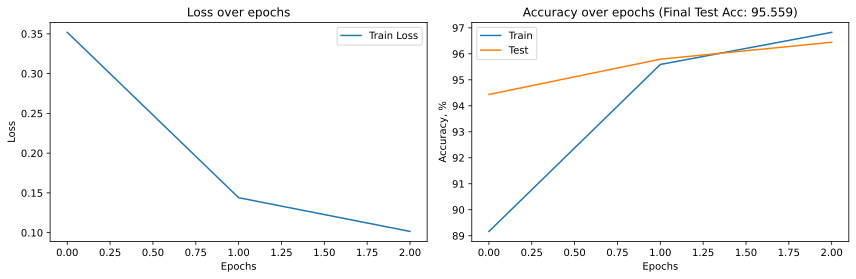

In [42]:
fig,axs = plt.subplots(1,2,figsize=(12,4))

axs[0].plot(losses, label='Train Loss')
axs[0].set_ylabel('Loss')
axs[0].set_title('Loss over epochs')

axs[1].plot(trainAcc, label='Train')
axs[1].plot(testAcc, label='Test')
axs[1].set_ylabel('Accuracy, %')
axs[1].set_title(f'Accuracy over epochs (Final Test Acc: {np.mean(testAcc[-10:]):.3f})')

for a in axs:
    a.set_xlabel('Epochs')
    a.legend()

fig.tight_layout()
plt.show()

# Test trained model on unseen dropepd data

In [45]:
dataDroppedNormT   = torch.tensor( dataDroppedNorm ).float()
labelsDroppedT = torch.tensor( labelsDropped ).long() # long = int64

yHat = net(dataDroppedNormT)

matches = torch.argmax(yHat, axis=1) == labelsDroppedT
accuracy = 100 * torch.mean(matches.float())
print(f'Accuracy on dropped data: {accuracy:.2f}%')

Accuracy on dropped data: 0.00%


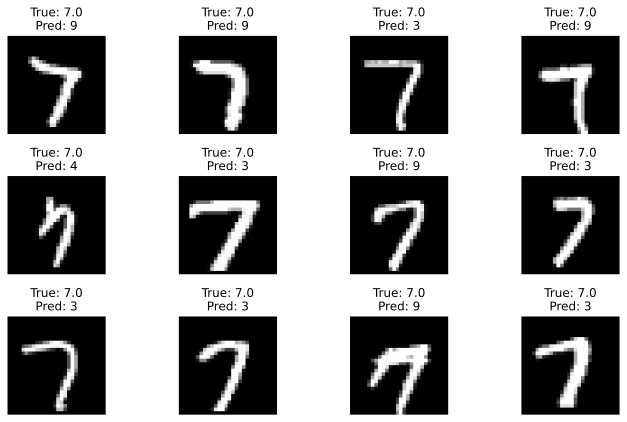

In [51]:
# Visualize some results
fig,axs = plt.subplots(3,4,figsize=(10,6))
for i in range(12):
    randomIdx = np.random.randint(0, dataDropped.shape[0])
    axs[i//4,i%4].imshow( dataDropped[randomIdx,:].reshape(28,28), cmap='gray' )
    axs[i//4,i%4].axis('off')
    axs[i//4,i%4].set_title( f'True: {labelsDropped[randomIdx]}\nPred: {torch.argmax(yHat,axis=1)[randomIdx].item()}' )
fig.tight_layout()
plt.show()

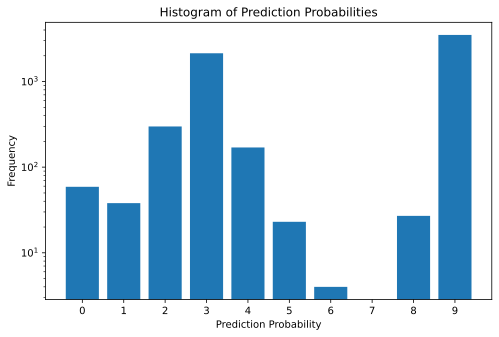

In [111]:
yHatHist = (torch.argmax(yHat, axis=1)).detach().numpy().flatten()
numsProb, _ = np.histogram(yHatHist, bins=np.arange(-0.5, 10.5, 1))

plt.figure(figsize=(8, 5))
plt.bar(range(len(numsProb)), numsProb)
plt.xticks(range(len(numsProb)))
plt.xlabel('Prediction Probability')
plt.ylabel('Frequency')
plt.title('Histogram of Prediction Probabilities')
plt.yscale('log')  # Use log scale for better visualization
plt.show()